In [272]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder



In [273]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [274]:
df.shape

(1338, 7)

In [275]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [276]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [277]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [278]:
df.duplicated().sum()

np.int64(1)

In [279]:
duplicate_mask = df.duplicated(keep=False)
df[duplicate_mask]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [280]:
df = df.drop_duplicates()

In [281]:
y = df['charges']
X = df.drop('charges', axis=1)

In [282]:
X.shape, y.shape

((1337, 6), (1337,))

In [283]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [284]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

In [285]:
log_y_train = y_train.map(lambda x: np.log(x))

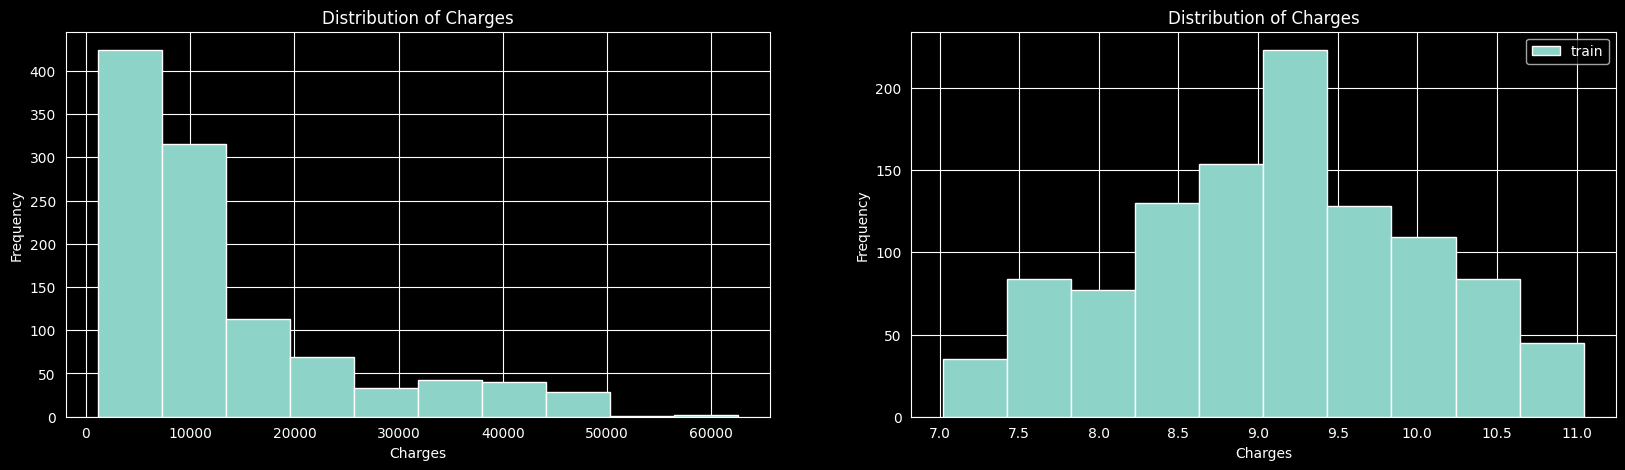

In [286]:
fig, ax = plt.subplots(1,2, figsize=(20,5))

ax[0].hist(y_train, bins=10, label='train')
ax[1].hist(log_y_train, bins=10, label='train')

ax[0].set_xlabel("Charges")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Distribution of Charges")

ax[1].set_xlabel("Charges")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Distribution of Charges")

plt.legend()
plt.show()


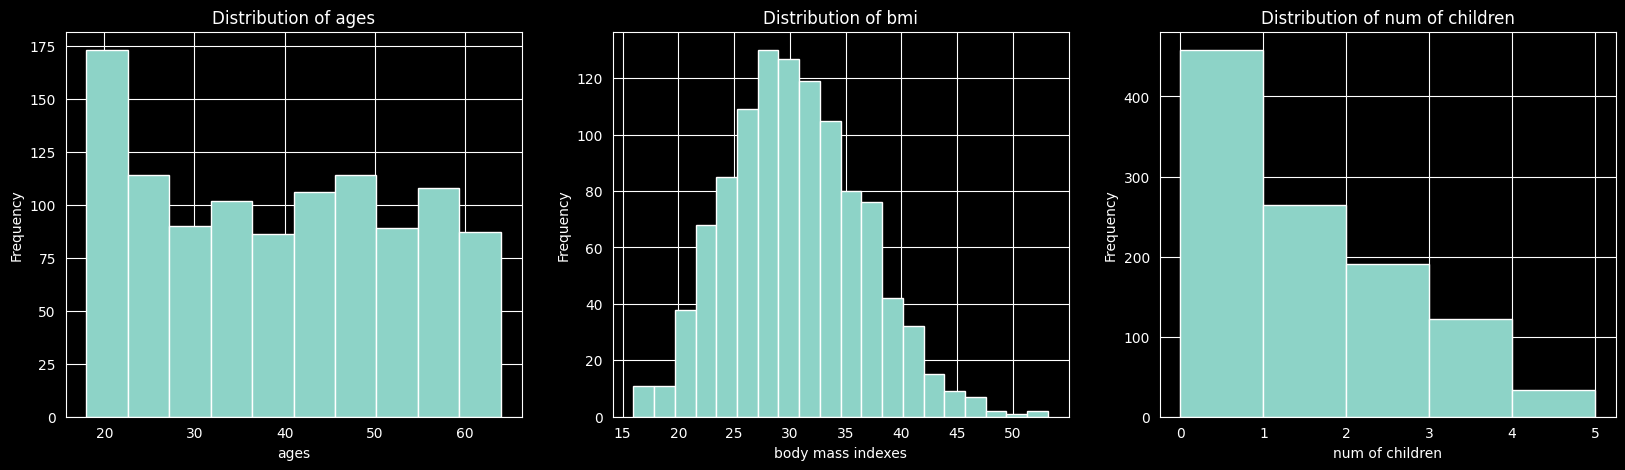

In [287]:
fig, axes = plt.subplots(1,3, figsize=(20,5))


axes[0].hist(X_train['age'], bins=10, label='train')
axes[0].set_xlabel("ages")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of ages")

axes[1].hist(X_train['bmi'], bins=20, label='train')
axes[1].set_xlabel("body mass indexes")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of bmi")

axes[2].hist(X_train['children'], bins=5, label='train')
axes[2].set_xlabel("num of children")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Distribution of num of children")



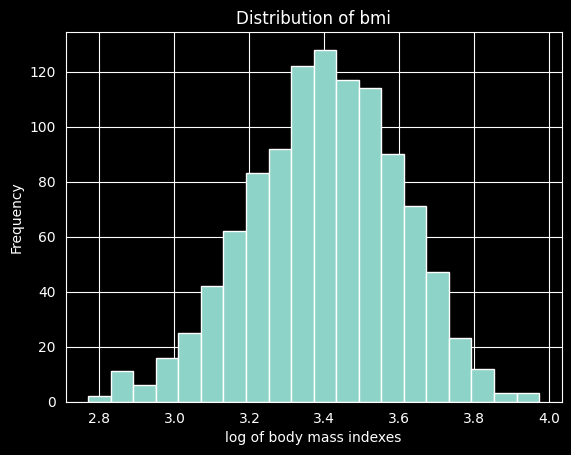

In [288]:
log_bmi = X_train['bmi'].map(lambda x: np.log(x))

plt.hist(log_bmi, bins=20, label='train')

plt.xlabel('log of body mass indexes')
plt.ylabel('Frequency')
plt.title("Distribution of bmi")
plt.show()

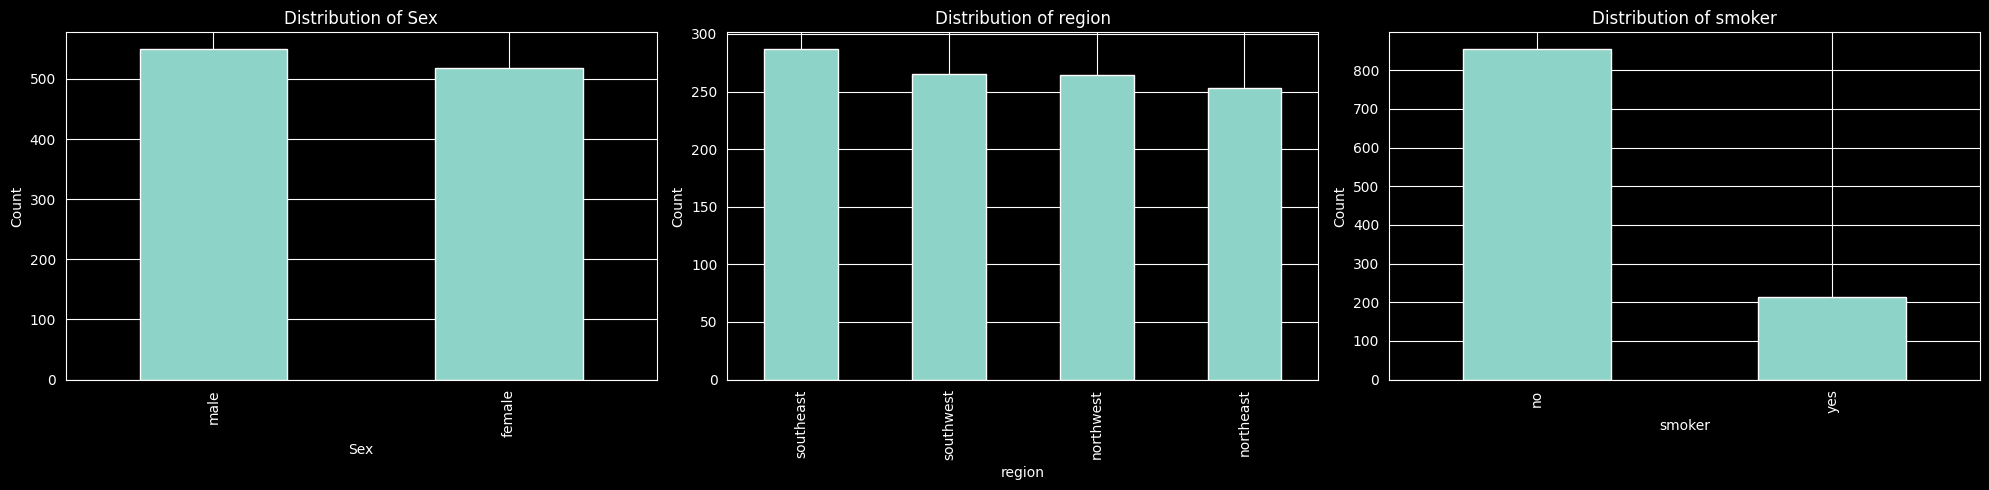

In [289]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

X_train['sex'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Sex")

X_train['region'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_xlabel("region")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of region")

X_train['smoker'].value_counts().plot(kind='bar', ax=axes[2])
axes[2].set_xlabel("smoker")
axes[2].set_ylabel("Count")
axes[2].set_title("Distribution of smoker")

plt.tight_layout()
plt.show()

In [290]:

enc = OneHotEncoder()

X_train_cat_encoded = enc.fit_transform(X_train[['sex', 'region', 'smoker']])
X_train_cat_encoded = pd.DataFrame(X_train_cat_encoded.toarray(), columns=enc.get_feature_names_out(['sex', 'region', 'smoker']))

In [291]:
X_train_cat_encoded.head()


,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [292]:
X_train = pd.concat([X_train, X_train_cat_encoded], axis=1)


In [293]:
X_train.drop(['sex', 'region', 'smoker'], axis=1, inplace=True)
X_train.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
0,23,24.510,0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,21,25.745,2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,52,37.525,2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,63,41.470,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,47,26.600,2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [294]:
y_train.shape, X_train.shape

((1069,), (1069, 11))

In [295]:
df_encoded = pd.concat([X_train, y_train], axis=1)

In [296]:
df_encoded.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes,charges
0,23,24.510,0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,2396.09590
1,21,25.745,2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,3279.86855
2,52,37.525,2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,33471.97189
3,63,41.470,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,13405.39030
4,47,26.600,2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,9715.84100


In [297]:
corr_matrix = df_encoded.corr()

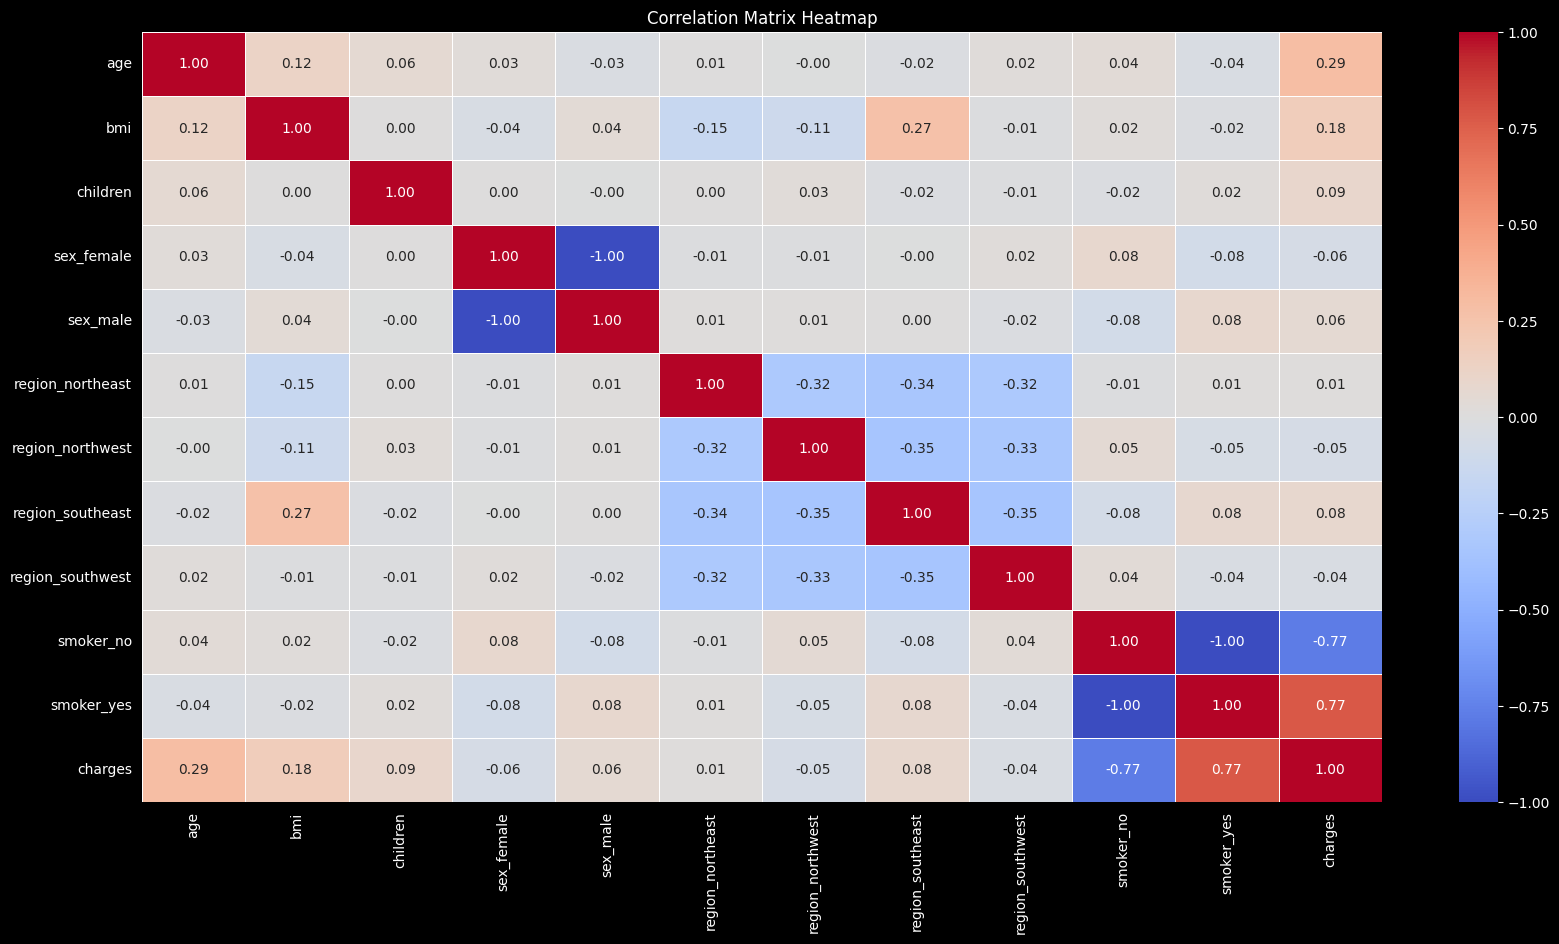

In [298]:
plt.figure(figsize=(20,10))
sns.heatmap(data=corr_matrix, annot=True, cmap="coolwarm",vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix Heatmap')
plt.show()

In [299]:
df_encoded.describe()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes,charges
count,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000,1069.000000
mean,39.198316,30.540426,1.084191,0.485500,0.514500,0.236670,0.246960,0.268475,0.247895,0.799813,0.200187,13030.203369
std,13.998594,6.051841,1.194723,0.500024,0.500024,0.425237,0.431445,0.443374,0.431993,0.400328,0.400328,11706.530971
min,18.000000,15.960000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,26.180000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,4747.052900
50%,39.000000,30.200000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,9290.139500
75%,51.000000,34.430000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,16450.894700
max,64.000000,53.130000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,62592.873090


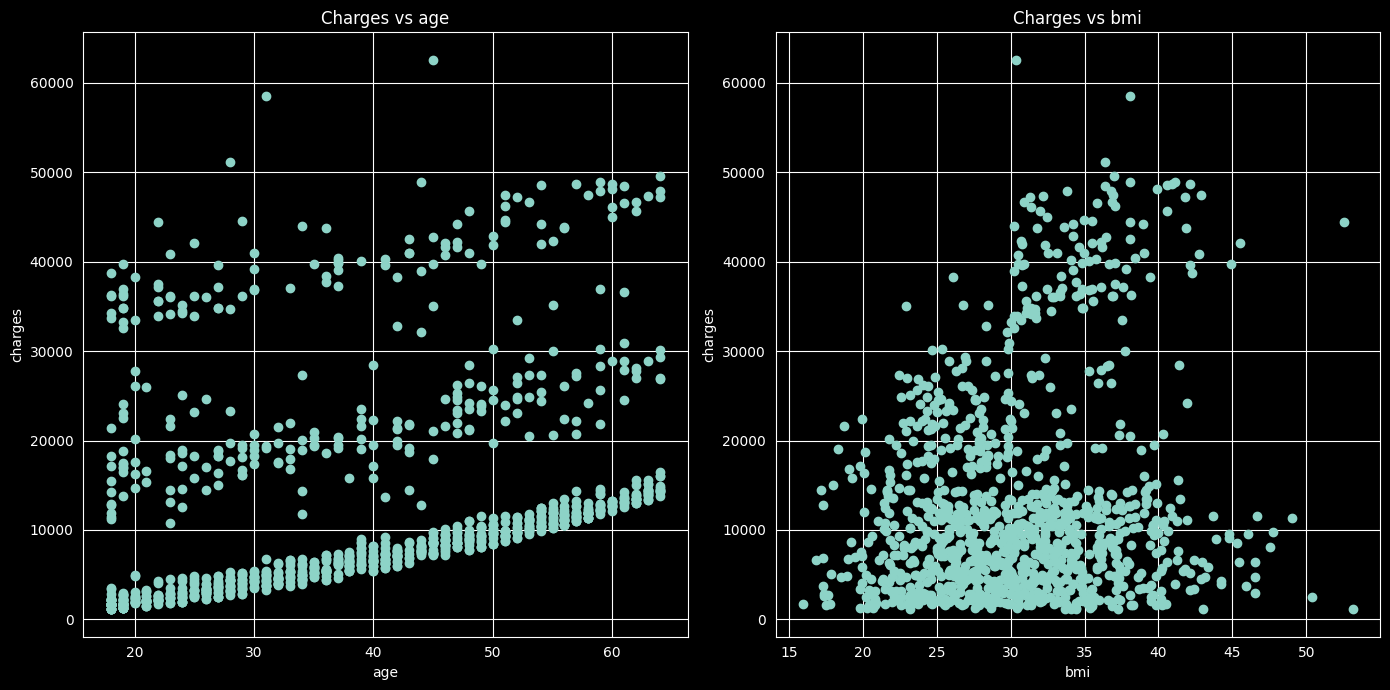

In [300]:
fig, ax = plt.subplots(1,2,figsize=(14,7))


ax[0].scatter(df_encoded['age'], df_encoded['charges'])
ax[0].set_xlabel('age')
ax[0].set_ylabel('charges')
ax[0].set_title('Charges vs age')

ax[1].scatter(df_encoded['bmi'], df_encoded['charges'])
ax[1].set_xlabel('bmi')
ax[1].set_ylabel('charges')
ax[1].set_title("Charges vs bmi")

plt.tight_layout()


In [301]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


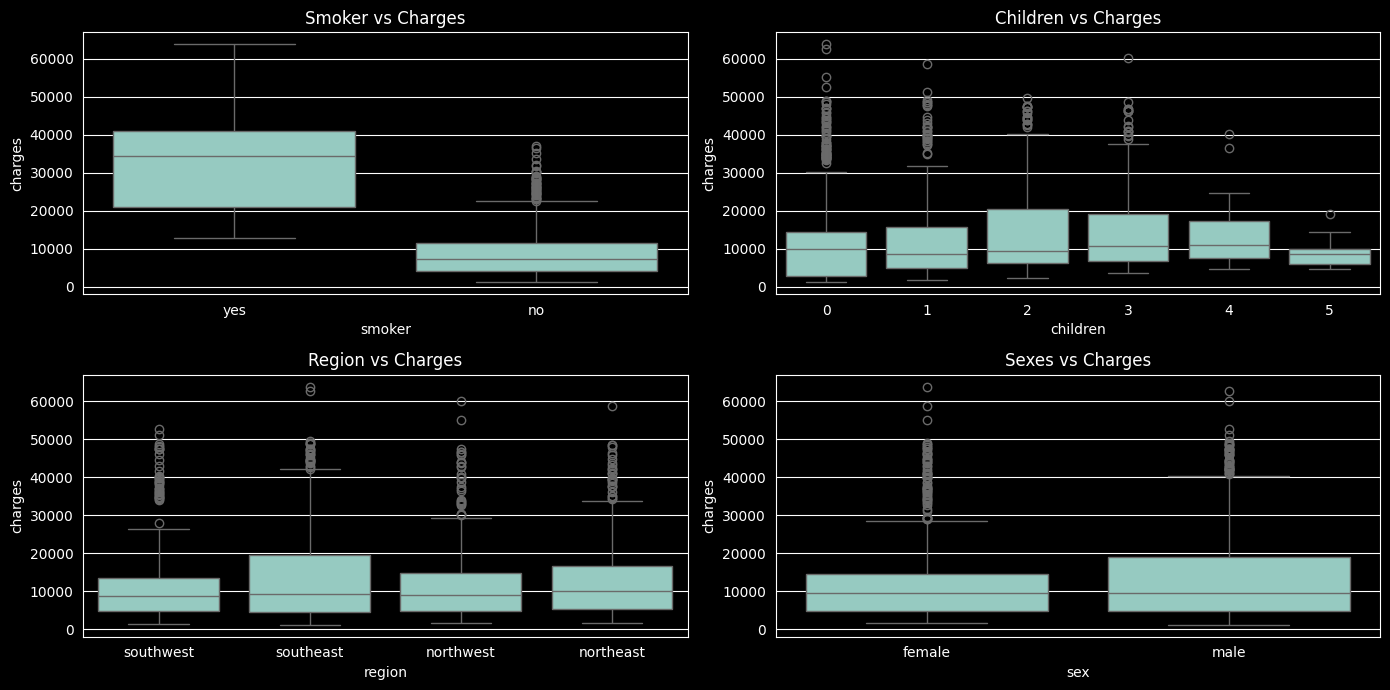

In [302]:
fig, ax = plt.subplots(2, 2, figsize=(14, 7))

sns.boxplot(x='smoker', y='charges', data=df, ax=ax[0,0])
ax[0,0].set_title('Smoker vs Charges')

sns.boxplot(x='children', y='charges', data=df, ax=ax[0,1])
ax[0,1].set_title('Children vs Charges')

sns.boxplot(x='region', y='charges', data=df, ax=ax[1,0])
ax[1,0].set_title('Region vs Charges')

sns.boxplot(x='sex', y='charges', data=df, ax=ax[1,1])
ax[1,1].set_title('Sexes vs Charges')

plt.tight_layout()
plt.show()

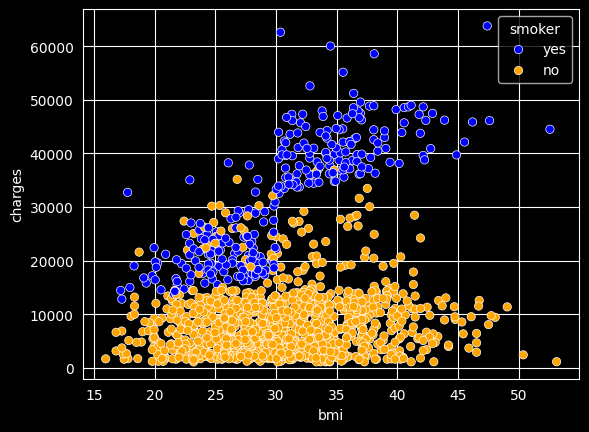

In [303]:
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker',    palette=['blue', 'orange'])

In [304]:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


upper, lower

(np.float64(34524.777625), np.float64(-13120.716174999998))

In [305]:
df_statistical_outliers = df[(df['charges']>upper) | (df['charges']<lower)]

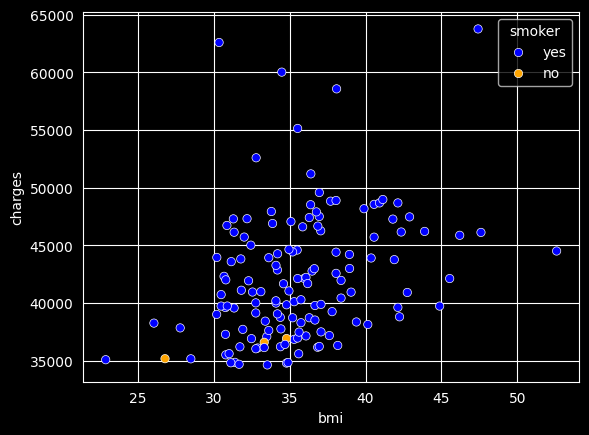

In [306]:
sns.scatterplot(data=df_statistical_outliers, x='bmi', y='charges', hue='smoker',    palette=['blue', 'orange'])


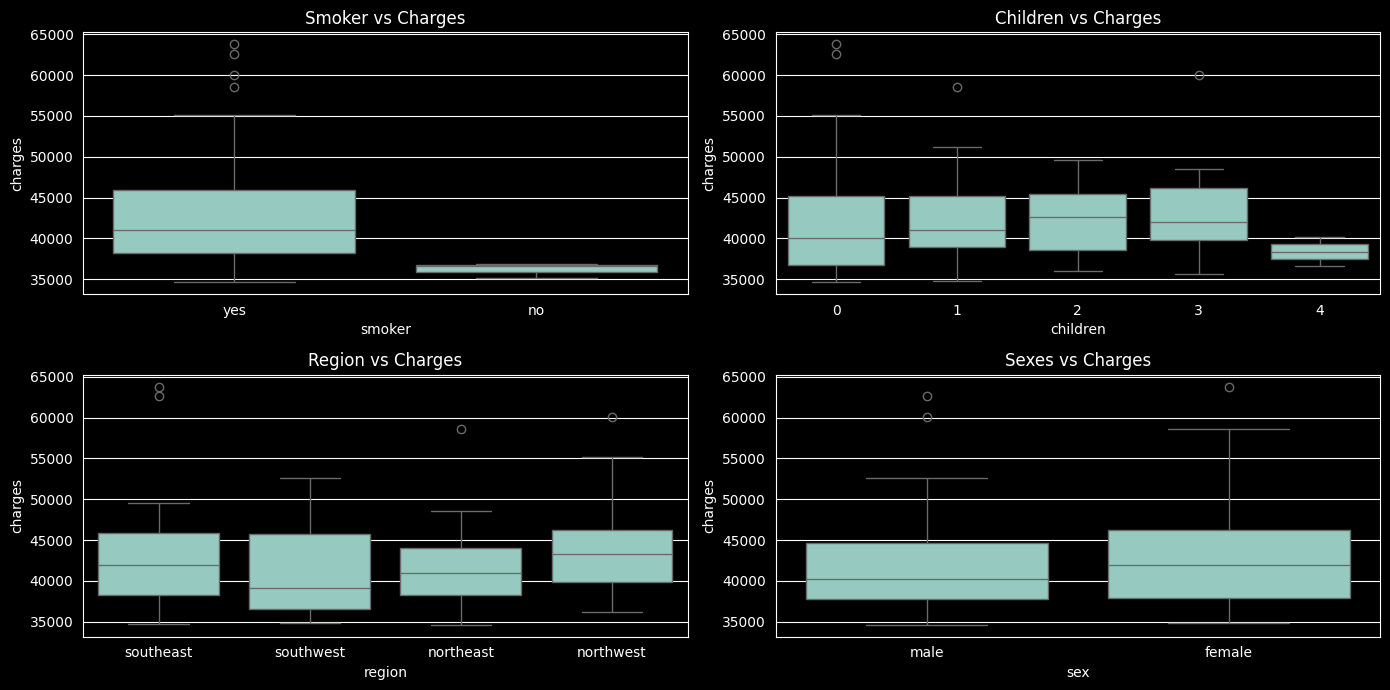

In [307]:
fig, ax = plt.subplots(2, 2, figsize=(14, 7))

sns.boxplot(x='smoker', y='charges', data=df_statistical_outliers, ax=ax[0,0])
ax[0,0].set_title('Smoker vs Charges')

sns.boxplot(x='children', y='charges', data=df_statistical_outliers, ax=ax[0,1])
ax[0,1].set_title('Children vs Charges')

sns.boxplot(x='region', y='charges', data=df_statistical_outliers, ax=ax[1,0])
ax[1,0].set_title('Region vs Charges')

sns.boxplot(x='sex', y='charges', data=df_statistical_outliers, ax=ax[1,1])
ax[1,1].set_title('Sexes vs Charges')

plt.tight_layout()
plt.show()

In [308]:
df['bmi'][df['smoker']=='yes'].mode(), df['bmi'][df['smoker']=='no'].mode()


(0    28.31
 Name: bmi, dtype: float64,
 0    32.3
 Name: bmi, dtype: float64)

In [309]:
train = df_encoded.copy()

In [310]:
def bmi_category(bmi):
    if bmi<18.5:
        return "underweight"
    elif bmi<25:
        return "normal"
    elif bmi<30:
        return "overweight"
    else:
        return "obese"


train['bmi_category'] = train['bmi'].apply(bmi_category)
train['smoker_age'] = train['smoker_yes'] * train['age']
train['bmi_smoker'] = train['bmi'] * train['smoker_yes']
train['age_group'] = pd.cut(train['age'], bins=[18,30,45,60,100])

In [311]:
train.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes,charges,bmi_category,smoker_age,bmi_smoker,age_group
0,23,24.510,0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,2396.09590,normal,0.0,0.0,"(18, 30]"
1,21,25.745,2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,3279.86855,overweight,0.0,0.0,"(18, 30]"
2,52,37.525,2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,33471.97189,obese,0.0,0.0,"(45, 60]"
3,63,41.470,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,13405.39030,obese,0.0,0.0,"(60, 100]"
4,47,26.600,2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,9715.84100,overweight,0.0,0.0,"(45, 60]"


In [312]:
enc = OneHotEncoder()

train_encoded = enc.fit_transform(train[['bmi_category']])
train_encoded = pd.DataFrame(train_encoded.toarray(), columns=enc.get_feature_names_out(['bmi_category']))

train = pd.concat([train, train_encoded], axis=1)

In [313]:
train.drop('bmi_category', axis=1, inplace=True)

In [314]:
train = pd.get_dummies(train, columns=['age_group'], drop_first=False)

In [318]:
y_col = train.pop('charges')
train.insert(len(train.columns), 'charges', y_col)
train['log_charges'] = log_y_train




In [320]:
train.columns

Index(['age', 'bmi', 'children', 'sex_female', 'sex_male', 'region_northeast',
       'region_northwest', 'region_southeast', 'region_southwest', 'smoker_no',
       'smoker_yes', 'smoker_age', 'bmi_smoker', 'bmi_category_normal',
       'bmi_category_obese', 'bmi_category_overweight',
       'bmi_category_underweight', 'age_group_(18, 30]', 'age_group_(30, 45]',
       'age_group_(45, 60]', 'age_group_(60, 100]', 'charges', 'log_charges'],
      dtype='str')

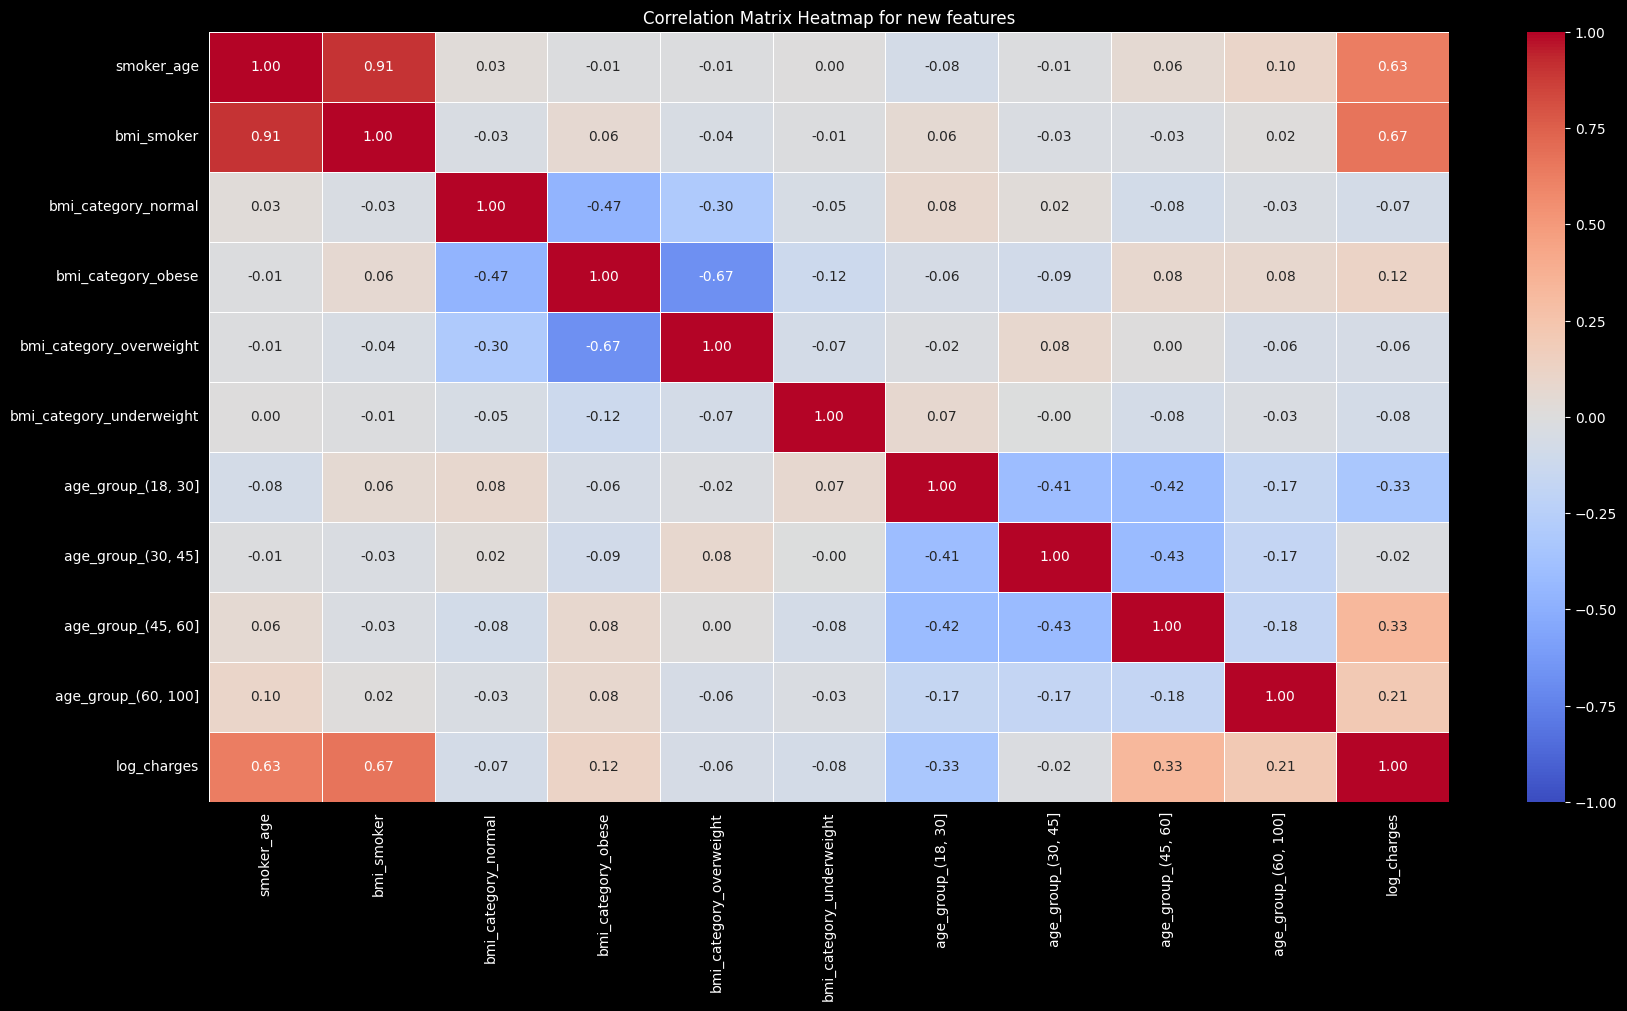

In [322]:
plt.figure(figsize=(20,10))
sns.heatmap(data=train[['smoker_age', 'bmi_smoker', 'bmi_category_normal',
       'bmi_category_obese', 'bmi_category_overweight',
       'bmi_category_underweight', 'age_group_(18, 30]', 'age_group_(30, 45]',
       'age_group_(45, 60]', 'age_group_(60, 100]', 'log_charges']].corr(), annot=True, cmap="coolwarm",vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix Heatmap for new features')
plt.show()